In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### LOADING AND CLEANING THE DATASET
Loaded the dataset as a CSV file through `read_csv()` function.
Renamed the columns for better readability and displayed a few of the values.

In [2]:
df = pd.read_csv("whp_2017.csv")
df.head()
#renaming columns
df.rename(columns={"Happiness.Rank":"Happiness_Rank","Happiness.Score":"Happiness_Score","Whisker.high":"Whisker_High","Whisker.low":"Whisker_Low","Economy..GDP.per.Capita.":"GDP_per_Capita","Health..Life.Expectancy.":"Life_Expectancy","Trust..Government.Corruption.":"Corruption_Perception","Dystopia.Residual":"Dystopia_Residual"}, inplace=True)
df.tail()

,Country,Happiness_Rank,Happiness_Score,Whisker_High,Whisker_Low,GDP_per_Capita,Family,Life_Expectancy,Freedom,Generosity,Corruption_Perception,Dystopia_Residual
150,Rwanda,151,3.471,3.543030,3.398970,0.368746,0.945707,0.326425,0.581844,0.252756,0.455220,0.540061
151,Syria,152,3.462,3.663669,3.260331,0.777153,0.396103,0.500533,0.081539,0.493664,0.151347,1.061574
152,Tanzania,153,3.349,3.461430,3.236570,0.511136,1.041990,0.364509,0.390018,0.354256,0.066035,0.621130
153,Burundi,154,2.905,3.074690,2.735310,0.091623,0.629794,0.151611,0.059901,0.204435,0.084148,1.683024
154,Central African Republic,155,2.693,2.864884,2.521116,0.000000,0.000000,0.018773,0.270842,0.280876,0.056565,2.066005


Here I have found the cells that have 0 (basically NA) that might skew our results while performing EDA (if any), and in the next step removed those rows.

In [3]:
#finding empty columns
empty_cols = (df == 0).sum().sum()
print(empty_cols)

6


In [4]:
#Removing rows with empty columns
df.drop(df[(df == 0).any(axis=1)].index, inplace=True)

### Top 10 Happiest Countries

In [5]:
print("Top 10 Happiest Countries")
df.head(10)

Top 10 Happiest Countries


,Country,Happiness_Rank,Happiness_Score,Whisker_High,Whisker_Low,GDP_per_Capita,Family,Life_Expectancy,Freedom,Generosity,Corruption_Perception,Dystopia_Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715
3,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716
4,Finland,5,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182
5,Netherlands,6,7.377,7.427426,7.326574,1.503945,1.428939,0.810696,0.585384,0.470490,0.282662,2.294804
6,Canada,7,7.316,7.384403,7.247597,1.479204,1.481349,0.834558,0.611101,0.435540,0.287372,2.187264
7,New Zealand,8,7.314,7.379510,7.248490,1.405706,1.548195,0.816760,0.614062,0.500005,0.382817,2.046456
8,Sweden,9,7.284,7.344095,7.223905,1.494387,1.478162,0.830875,0.612924,0.385399,0.384399,2.097538
9,Australia,10,7.284,7.356651,7.211349,1.484415,1.510042,0.843887,0.601607,0.477699,0.301184,2.065211


### Bottom 10 Happiest Countries

In [6]:
print("Bottom 10 Happiest Countries")
df.tail(10)

Bottom 10 Happiest Countries


,Country,Happiness_Rank,Happiness_Score,Whisker_High,Whisker_Low,GDP_per_Capita,Family,Life_Expectancy,Freedom,Generosity,Corruption_Perception,Dystopia_Residual
144,Haiti,145,3.603,3.734715,3.471285,0.368610,0.640450,0.277321,0.030370,0.489204,0.099872,1.697168
145,Yemen,146,3.593,3.692750,3.493250,0.591683,0.935382,0.310081,0.249464,0.104125,0.056767,1.345601
146,South Sudan,147,3.591,3.725539,3.456462,0.397249,0.601323,0.163486,0.147062,0.285671,0.116794,1.879567
147,Liberia,148,3.533,3.653756,3.412244,0.119042,0.872118,0.229918,0.332881,0.266550,0.038948,1.673286
148,Guinea,149,3.507,3.584428,3.429572,0.244550,0.791245,0.194129,0.348588,0.264815,0.110938,1.552312
149,Togo,150,3.495,3.594038,3.395962,0.305445,0.431883,0.247106,0.380426,0.196896,0.095665,1.837229
150,Rwanda,151,3.471,3.543030,3.398970,0.368746,0.945707,0.326425,0.581844,0.252756,0.455220,0.540061
151,Syria,152,3.462,3.663669,3.260331,0.777153,0.396103,0.500533,0.081539,0.493664,0.151347,1.061574
152,Tanzania,153,3.349,3.461430,3.236570,0.511136,1.041990,0.364509,0.390018,0.354256,0.066035,0.621130
153,Burundi,154,2.905,3.074690,2.735310,0.091623,0.629794,0.151611,0.059901,0.204435,0.084148,1.683024


### STATISTICS
Using describe() function we get the 
    1. Count
    2. Mean
    3. Standard Deviation
    4. Minimum value in the column
    5. 1st Quartile
    6. Median (2nd Quartile)
    7. 3rd Quartile
    8. Maximum value in the column


In [7]:
#Descriptive Statistics of the data
df.describe()

,Happiness_Rank,Happiness_Score,Whisker_High,Whisker_Low,GDP_per_Capita,Family,Life_Expectancy,Freedom,Generosity,Corruption_Perception,Dystopia_Residual
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,76.526667,5.394453,5.490987,5.297920,0.993200,1.197839,0.559159,0.416001,0.249345,0.125300,1.853568
std,44.591012,1.113909,1.103607,1.125265,0.417438,0.274884,0.227570,0.144956,0.134554,0.102389,0.506414
min,1.000000,2.905000,3.074690,2.735310,0.022643,0.396103,0.005565,0.014996,0.010165,0.004388,0.377914
25%,38.250000,4.537500,4.627970,4.379207,0.679481,1.042312,0.398654,0.313921,0.155970,0.059416,1.587952
50%,75.500000,5.317500,5.425725,5.225156,1.069970,1.258944,0.609627,0.443255,0.232678,0.090523,1.833961
75%,114.750000,6.152250,6.335461,6.018500,1.324265,1.419041,0.724903,0.519885,0.324529,0.154897,2.167007
max,154.000000,7.537000,7.622030,7.479556,1.870766,1.610574,0.949492,0.658249,0.838075,0.464308,3.117485


### Correlation Heatmap
Values close to -1 indicate strong negative correlation, +1 indicate strong positive correlation and 0 indicate no linear relationship.

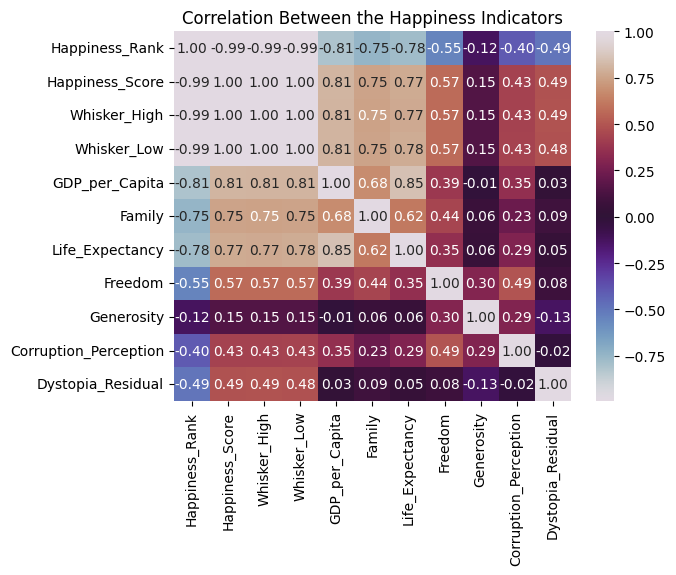

In [ ]:
corr_matrix = df.iloc[:,1:].corr()
plt.figure()
plt.title(label ="Correlation Between the Happiness Indicators");
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="twilight" )
plt.show()

We didn't include name as name of a country does not determine its happiness index. But again we see that we have redundant values like whiskers and between happiness rank and happiness score; whiskers indicate the margin of error of the happiness score and move together thus have a high correlation and will be removed, happiness rank is an ordered version of happiness score, so it has no relevance to be included and will be removed in the following step.

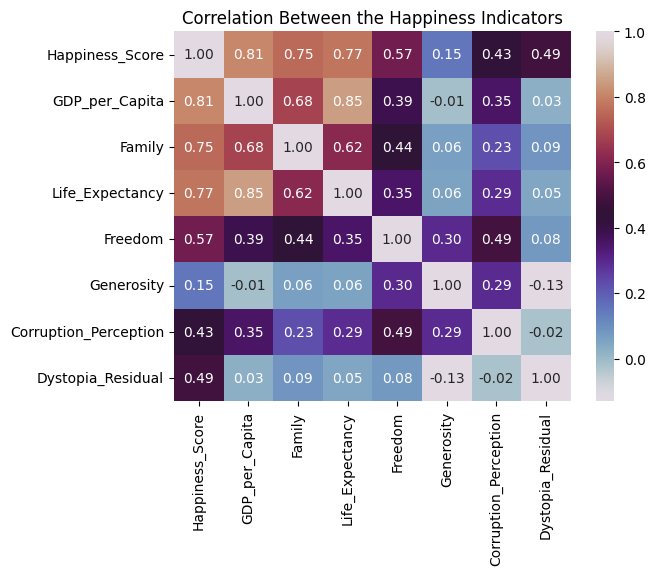

In [9]:
corr_matrix = df[['Happiness_Score','GDP_per_Capita','Family','Life_Expectancy','Freedom', 'Generosity','Corruption_Perception', 'Dystopia_Residual']].corr() #using column names as it is more readable
plt.figure()
plt.title(label ="Correlation Between the Happiness Indicators");
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="twilight" )
plt.show()

### Pearson Correlation Coefficient between GDP per capita and Happiness Score
This reflects the same values given in the first row of the correlation matrix.

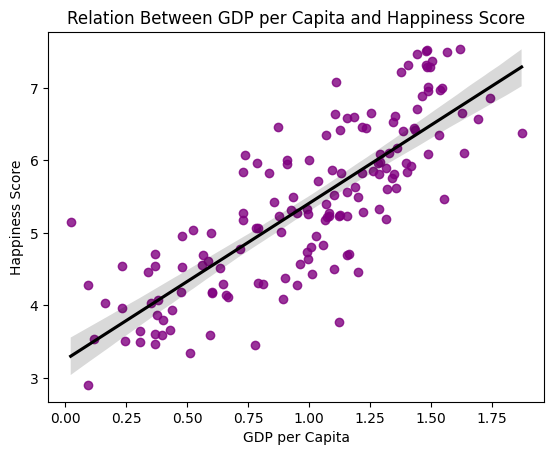

Pearson's Correlation: 0.8084


In [10]:
from scipy.stats import pearsonr
x = df["GDP_per_Capita"]
y = df["Happiness_Score"]
sns.regplot(x=x,y=y,scatter_kws={"color":"purple"}, line_kws={"color":"black"})
plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")
plt.title("Relation Between GDP per Capita and Happiness Score")
plt.show()
corr, _ = pearsonr(x,y)
print("Pearson's Correlation: %.4f" % corr)

### Pearson Correlation Coefficient between Social Support/Family and Happiness Score

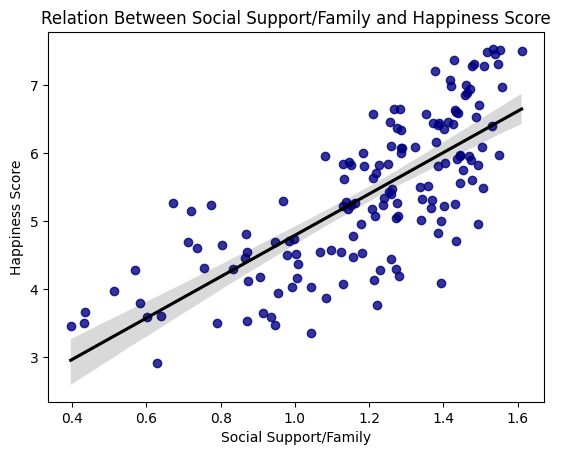

Pearson's Correlation: 0.7520


In [ ]:
x = df["Family"]
y = df["Happiness_Score"]
sns.regplot(x=x,y=y,scatter_kws={"color":"navy"}, line_kws={"color":"black"})
plt.xlabel("Social Support/Family")
plt.ylabel("Happiness Score")
plt.title("Relation Between Social Support/Family and Happiness Score")
plt.show()
corr, _ = pearsonr(x,y)
print("Pearson's Correlation: %.4f" % corr)

### Pearson Correlation Coefficient between Life Expectancy and Happiness Score

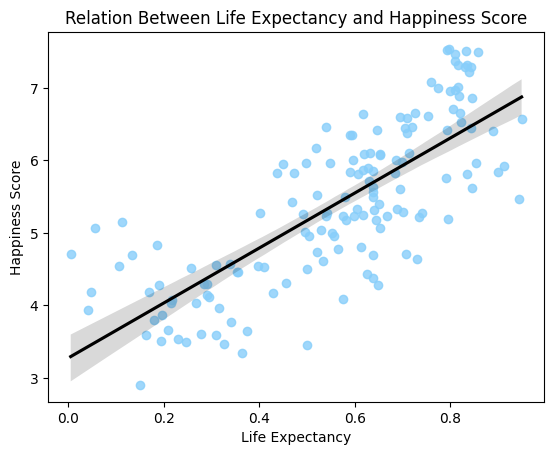

Pearson's Correlation: 0.7746


In [ ]:
x = df["Life_Expectancy"]
y = df["Happiness_Score"]
sns.regplot(x=x,y=y,scatter_kws={"color":"lightskyblue"}, line_kws={"color":"black"})
plt.xlabel("Life Expectancy")
plt.ylabel("Happiness Score")
plt.title("Relation Between Life Expectancy and Happiness Score")
plt.show()
corr, _ = pearsonr(x,y)
print("Pearson's Correlation: %.4f" % corr)

### Pearson Correlation Coefficient between Freedom and Happiness Score

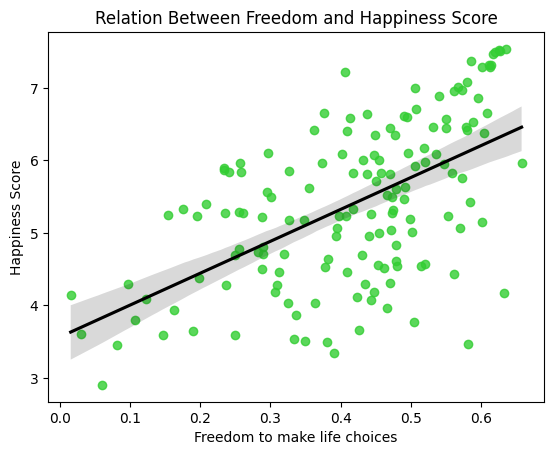

Pearson's Correlation: 0.5714


In [ ]:
x = df["Freedom"]
y = df["Happiness_Score"]
sns.regplot(x=x,y=y,scatter_kws={"color":"limegreen"}, line_kws={"color":"black"})
plt.xlabel("Freedom to make life choices")
plt.ylabel("Happiness Score")
plt.title("Relation Between Freedom and Happiness Score")
plt.show()
corr, _ = pearsonr(x,y)
print("Pearson's Correlation: %.4f" % corr)

### Pearson Correlation Coefficient between Life Expectancy and Happiness Score

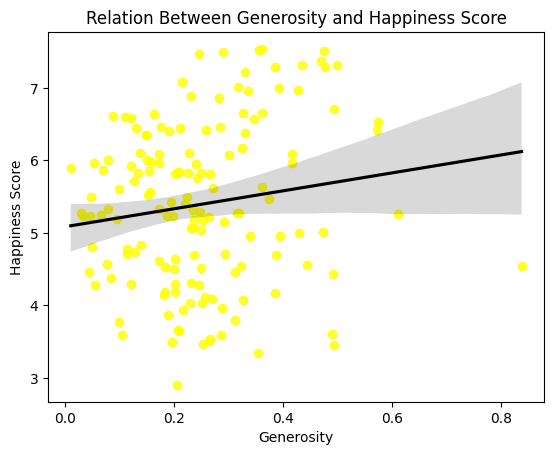

Pearson's Correlation: 0.1493


In [12]:
x = df["Generosity"]
y = df["Happiness_Score"]
sns.regplot(x=x,y=y,scatter_kws={"color":"yellow"}, line_kws={"color":"black"})
plt.xlabel("Generosity")
plt.ylabel("Happiness Score")
plt.title("Relation Between Generosity and Happiness Score")
plt.show()
corr, _ = pearsonr(x,y)
print("Pearson's Correlation: %.4f" % corr)

### Pearson Correlation Coefficient between Corruption and Happiness Score

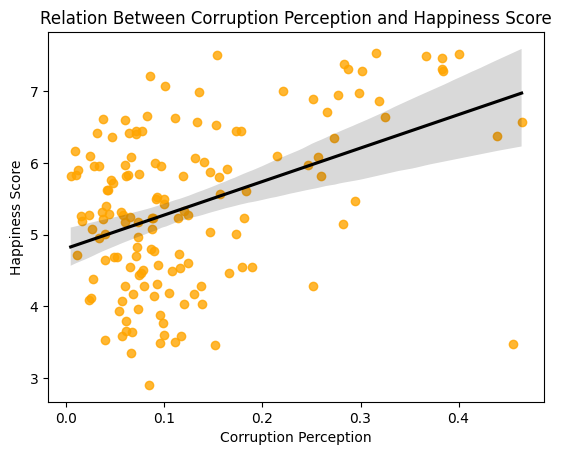

Pearson's Correlation: 0.4289


In [15]:
from scipy.stats import pearsonr
x = df["Corruption_Perception"]
y = df["Happiness_Score"]
sns.regplot(x=x,y=y,scatter_kws={"color":"orange"}, line_kws={"color":"black"})
plt.xlabel("Corruption Perception")
plt.ylabel("Happiness Score")
plt.title("Relation Between Corruption Perception and Happiness Score")
plt.show()
corr, _ = pearsonr(x,y)
print("Pearson's Correlation: %.4f" % corr)

### IMPORTANCE OF FEATURES USING LINEAR REGRESSION
Using `fit_transform()` we find the mean and standard deviation and then train the model. Using this we find which has a better correlation to happiness score

              Feature  Coefficient
           Generosity     0.045685
Corruption_Perception     0.088683
              Freedom     0.209303
      Life_Expectancy     0.278539
               Family     0.325985
       GDP_per_Capita     0.328017


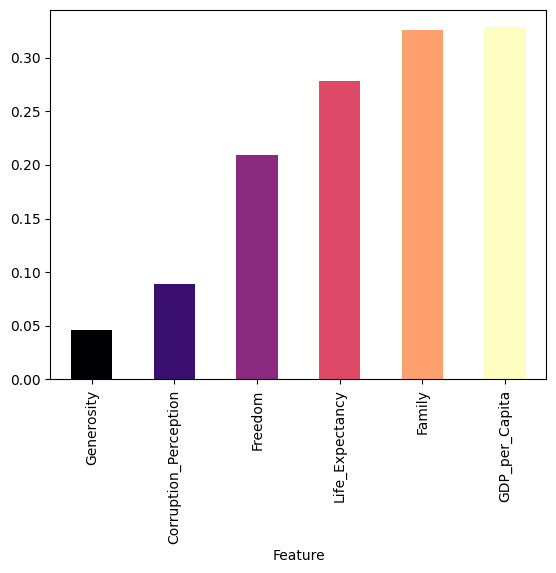

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

features =["GDP_per_Capita", "Family", "Life_Expectancy", "Freedom", "Generosity", "Corruption_Perception"]
X = df[features]
Y = df["Happiness_Score"]

scaler = StandardScaler() # z-score normalization
X_scale = scaler.fit_transform(X)
X_scale = pd.DataFrame(X_scale, columns=X.columns)

model = LinearRegression()
model.fit(X_scale, Y)

coefficients = pd.DataFrame({"Feature": features, "Coefficient": model.coef_})

coefficients_sort = coefficients.sort_values(by="Coefficient")
print(coefficients_sort.to_string(index=False))

colors = plt.cm.magma(np.linspace(0,1,len(coefficients_sort)))
f = coefficients_sort.plot.bar(x="Feature",y="Coefficient", rot = 90 , color=colors, legend = False)


### Evalution of the model's prediction
Now we check how well our regression model predicts scores and we inser the differences in our residual column. 

In [14]:
df["Predicted_Score"] = model.predict(X_scale)

df["Residual"] = df["Happiness_Score"] - df["Predicted_Score"]

scores = df[["Country", "Happiness_Score","Predicted_Score", "Residual"]]

print("Top 10 Countries with the Predicted Score")
print(scores.head(10))

print()
print("Bottom 10 Countries with the Predicted Score")
print(scores.tail(10))

print()
print("Countries with the largest residuals")
df.loc[df["Residual"].abs().nlargest(10).index, ["Country", "Residual"]]



Top 10 Countries with the Predicted Score
       Country  Happiness_Score  Predicted_Score  Residual
0       Norway            7.537         7.098907  0.438093
1      Denmark            7.522         7.066864  0.455136
2      Iceland            7.504         7.014338  0.489662
3  Switzerland            7.494         7.111806  0.382194
4      Finland            7.469         6.978846  0.490154
5  Netherlands            7.377         6.838504  0.538496
6       Canada            7.316         6.940106  0.375894
7  New Zealand            7.314         7.049037  0.264963
8       Sweden            7.284         7.013643  0.270357
9    Australia            7.284         7.002424  0.281576

Bottom 10 Countries with the Predicted Score
         Country  Happiness_Score  Predicted_Score  Residual
144        Haiti            3.603         3.393608  0.209392
145        Yemen            3.593         4.109415 -0.516415
146  South Sudan            3.591         3.344259  0.246741
147      Liberia   

,Country,Residual
141,Botswana,-1.546212
150,Rwanda,-1.373441
119,Sri Lanka,-1.370305
92,Somalia,1.215062
70,"Hong Kong S.A.R., China",-1.209295
152,Tanzania,-1.187493
79,Pakistan,1.142541
10,Israel,0.983772
28,Guatemala,0.972720
131,Ukraine,-0.969027


### Outlier Detection
Here, we are trying to find the outliers (using quartiles) in the happiness score and plotting them using box plot, if there are no outliers we simply skip them.

Outliers in Family
    Country    Family
142   Benin  0.435300
149    Togo  0.431883
151   Syria  0.396103



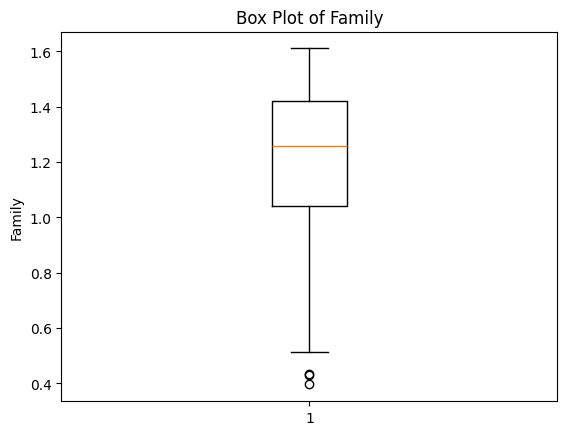

Outliers in Generosity
       Country  Generosity
80   Indonesia    0.611705
113    Myanmar    0.838075



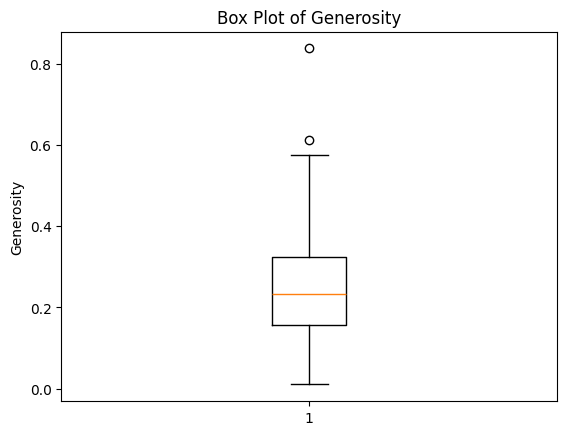

Outliers in Corruption_Perception
                  Country  Corruption_Perception
0                  Norway               0.315964
1                 Denmark               0.400770
3             Switzerland               0.367007
4                 Finland               0.382612
7             New Zealand               0.382817
8                  Sweden               0.384399
9               Australia               0.301184
14                Ireland               0.298388
17             Luxembourg               0.318834
20   United Arab Emirates               0.324490
25              Singapore               0.464308
34                  Qatar               0.439299
150                Rwanda               0.455220



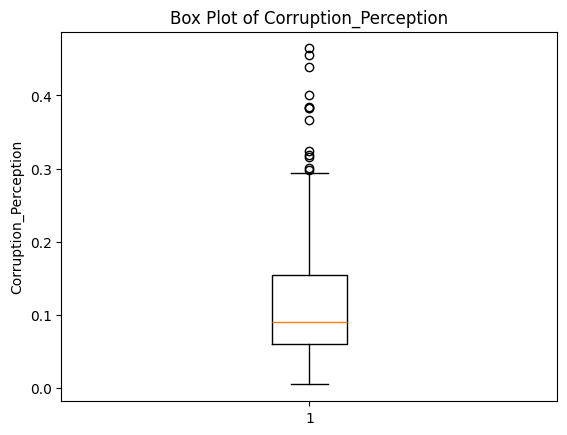

Outliers in Dystopia_Residual
                     Country  Dystopia_Residual
70   Hong Kong S.A.R., China           0.554633
92                   Somalia           3.117485
119                Sri Lanka           0.419389
141                 Botswana           0.377914
150                   Rwanda           0.540061
152                 Tanzania           0.621130



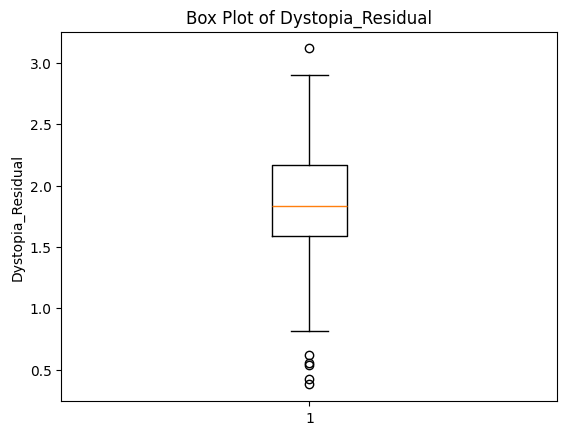

In [27]:
columns = [
    "Happiness_Score", 
    "GDP_per_Capita",
    "Family",
    "Life_Expectancy",
    "Freedom",
    "Generosity",
    "Corruption_Perception",
    "Dystopia_Residual"
]
for column in columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lb = q1 - 1.5*iqr
    ub = q3 + 1.5*iqr
    outliers = df[(df[column] < lb) | (df[column] > ub)]
    if not outliers.empty:
        print("Outliers in", column)
        print(outliers[["Country", column]])
        print()
        plt.figure()
        plt.boxplot(df[column])
        plt.title("Box Plot of "+ column)
        plt.ylabel(column)
        plt.show()
